# Task 2


The code works in log-price space and compares three local interpolation models around each gap: AR(1), Random walk, and GARCH(1,1).

For each series, the parameters are estimated from observed data before and after the gap. The missing block is then reconstructed conditional on the observed left and right endpoints, and 95% intervals are computed for all days.

The methods are compared with a leakage-safe backtest based on synthetic 50-day gaps placed inside observed parts of the series.


In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize
from scipy.stats import norm

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# shared settings
DATA_PATH = Path("../augmented_data/spiff_data_cleaned.csv")
TAIL_MISSING = 200
GAP_LENGTH = 50
LOCAL_WINDOW = 252
Z_95 = norm.ppf(0.975)

# keep the final forecast tail out of the interpolation task
data = pd.read_csv(DATA_PATH, index_col="day")
known_data = data.iloc[:-TAIL_MISSING].copy()

print(f"Data shape: {data.shape}")
print(f"Rows before the shared forecasting tail: {known_data.shape[0]}")
display(data.head())


Data shape: (5456, 7)
Rows before the shared forecasting tail: 5256


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.1547,2.7943,2.1365,10.6537,3.3249,3.8961,7.7559
2,6.1896,2.8431,2.1136,10.6745,3.3557,3.8999,7.7813
3,6.1686,2.8396,2.1163,10.8224,3.3365,3.8974,7.8862
4,6.1564,2.8234,2.0961,10.8488,3.2883,3.9012,7.8481
5,6.1249,2.8328,2.0998,10.8607,3.3037,3.9054,7.8830


In [23]:
def contiguous_groups(mask):
    # split missing values into contiguous blocks
    indices = np.flatnonzero(mask.to_numpy())
    if len(indices) == 0:
        return []
    split_points = np.where(np.diff(indices) > 1)[0] + 1
    return np.split(indices, split_points)


def find_internal_gap(series, tail_missing = TAIL_MISSING):
    missing_groups = contiguous_groups(series.isna())
    internal_groups = [group for group in missing_groups if group[-1] < len(series) - tail_missing]
    return internal_groups[0]


# store gap location for each series
gap_overview_rows = []
gap_map: dict[str, np.ndarray] = {}
for column in data.columns:
    gap = find_internal_gap(data[column])
    gap_map[column] = gap
    gap_overview_rows.append(
        {
            "series": column,
            "gap_start_day": int(data.index[gap[0]]),
            "gap_end_day": int(data.index[gap[-1]]),
            "gap_length": len(gap),
        }
    )

gap_overview = pd.DataFrame(gap_overview_rows)
display(gap_overview)


,series,gap_start_day,gap_end_day,gap_length
0,gurkor,199,248,50
1,guitars,399,448,50
2,slingshots,599,648,50
3,stocks,799,848,50
4,sugar,999,1048,50
5,water,1199,1248,50
6,tranquillity,1399,1448,50


## Why a local univariate setup?
The series show some dependence, but it is not strong enough across the full panel to justify a larger multivariate interpolation model here. A local univariate setup is simpler, uses the observed endpoints directly, and is easier to evaluate consistently across all series.


In [24]:
# compare log return dependence across series
log_return_corr = np.log(known_data).diff().dropna().corr()
display(log_return_corr.round(3))


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.0000,-0.2590,-0.2290,-0.0430,-0.0720,0.5740,-0.1380
guitars,-0.2590,1.0000,0.5300,0.0220,0.2070,-0.2450,0.2300
slingshots,-0.2290,0.5300,1.0000,0.0170,0.1170,-0.2110,0.1920
stocks,-0.0430,0.0220,0.0170,1.0000,-0.0140,-0.0430,0.0080
sugar,-0.0720,0.2070,0.1170,-0.0140,1.0000,-0.0790,0.1290
water,0.5740,-0.2450,-0.2110,-0.0430,-0.0790,1.0000,-0.1610
tranquillity,-0.1380,0.2300,0.1920,0.0080,0.1290,-0.1610,1.0000


## Interpolation models

- **AR(1)**: estimates a local mean-reverting process and fills the gap with the conditional Gaussian predictor.
- **Random walk**: treats log-returns as i.i.d. innovations and interpolates the gap as a variance bridge between the two observed endpoints.
- **GARCH(1,1)**: uses the same bridge idea as the random walk model, but allows the innovation variance to change over time through a local volatility recursion.

All three models produce point estimates and 95% intervals in log-price space.


In [25]:
MIN_AR1_PAIRS = 20
MIN_RETURN_PAIRS = 20
MIN_GARCH_PAIRS = 40
PHI_CLIP = 0.98
RIDGE = 1e-10
GARCH_PERSISTENCE_CAP = 0.995
INTERPOLATION_METHODS = ("ar1", "random_walk", "garch")

# helper functions for local parameter estimation and endpoint conditioning
METHOD_LABELS = {
    "ar1": "AR(1)",
    "random_walk": "Random walk",
    "garch": "GARCH(1,1)",
}


def _observed_series_without_tail(series, tail_missing = TAIL_MISSING):
    return series.iloc[:-tail_missing] if series.isna().sum() > tail_missing else series


def _valid_log_block(series):
    block = np.log(series.dropna())
    if len(block) < 2:
        return pd.Series(dtype=float)
    return block


def _get_local_log_blocks(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # collect observed log-price blocks on both sides of the gap
    left_block = _valid_log_block(series.iloc[max(0, gap_start - window):gap_start])
    right_block = _valid_log_block(series.iloc[gap_end + 1:min(len(series), gap_end + 1 + window)])

    sample_parts = [block for block in (left_block, right_block) if len(block) > 0]
    sample = pd.concat(sample_parts) if sample_parts else pd.Series(dtype=float)
    blocks = [block for block in (left_block, right_block) if len(block) >= 2]

    return left_block, right_block, sample, blocks


def _returns_from_blocks(blocks):
    return_parts = [np.diff(block.to_numpy()) for block in blocks if len(block) >= 2]
    if not return_parts:
        return np.array([])
    return np.concatenate(return_parts)


def estimate_local_ar1_params(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # fit ar1 on observed log prices around the gap
    left_block, right_block, sample, blocks = _get_local_log_blocks(series, gap_start, gap_end, window=window)

    x_prev_parts = [block.iloc[:-1].to_numpy() for block in blocks if len(block) >= 2]
    x_curr_parts = [block.iloc[1:].to_numpy() for block in blocks if len(block) >= 2]

    x_prev = np.concatenate(x_prev_parts)
    x_curr = np.concatenate(x_curr_parts)

    mu = float(sample.mean())
    x_prev_centered = x_prev - mu
    x_curr_centered = x_curr - mu

    denom = float(np.dot(x_prev_centered, x_prev_centered))
    phi = 0.0 if denom <= 0 else float(np.dot(x_prev_centered, x_curr_centered) / denom)
    phi = float(np.clip(phi, -PHI_CLIP, PHI_CLIP))

    residuals = x_curr_centered - phi * x_prev_centered
    sigma_eps = float(np.std(residuals, ddof=1))
    sigma_eps = max(sigma_eps, 1e-8)

    return mu, phi, sigma_eps


def estimate_local_random_walk_params(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # estimate drift and volatility from local log returns
    _, _, _, blocks = _get_local_log_blocks(series, gap_start, gap_end, window=window)
    returns = _returns_from_blocks(blocks)

    drift = float(np.mean(returns))
    sigma_return = float(np.std(returns, ddof=1))
    sigma_return = max(sigma_return, 1e-8)
    return drift, sigma_return


def _garch_filter(centered_returns, omega, alpha, beta, initial_variance = None):
    # propagate the conditional variance recursion forward
    if initial_variance is None:
        unconditional = omega / max(1 - alpha - beta, 1e-6)
        initial_variance = max(float(np.var(centered_returns, ddof=1)) if len(centered_returns) > 1 else unconditional, 1e-8)
    variances = np.empty(len(centered_returns), dtype=float)
    prev_var = max(initial_variance, 1e-8)
    for i, shock in enumerate(centered_returns):
        prev_var = omega + alpha * shock**2 + beta * prev_var
        variances[i] = max(prev_var, 1e-8)
    return variances


def estimate_local_garch_params(series, gap_start, gap_end, window = LOCAL_WINDOW):
    # fit a simple garch recursion to local log returns
    left_block, _, _, blocks = _get_local_log_blocks(series, gap_start, gap_end, window=window)
    returns = _returns_from_blocks(blocks)


    sample_var = max(float(np.var(returns, ddof=1)), 1e-8)

    def objective(params):
        # gaussian quasi-likelihood under the variance recursion
        drift, omega, alpha, beta = params
        if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= GARCH_PERSISTENCE_CAP:
            return np.inf
        centered = returns - drift
        variances = _garch_filter(centered, omega, alpha, beta, initial_variance=sample_var)
        return 0.5 * float(np.sum(np.log(variances) + centered**2 / variances))

    start = np.array([
        float(np.mean(returns)),
        sample_var * 0.05,
        0.08,
        0.88,
    ])
    bounds = [
        (None, None),
        (1e-8, None),
        (0.0, 0.4),
        (0.0, 0.999),
    ]
    result = minimize(objective, start, method="L-BFGS-B", bounds=bounds)

    if result.success:
        drift, omega, alpha, beta = map(float, result.x)
        if alpha + beta >= GARCH_PERSISTENCE_CAP:
            scale = (GARCH_PERSISTENCE_CAP - 1e-4) / (alpha + beta)
            alpha *= scale
            beta *= scale
    else:
        drift = float(np.mean(returns))
        alpha, beta = 0.08, 0.88
        omega = max(sample_var * (1 - alpha - beta), 1e-8)

    left_returns = np.diff(left_block.to_numpy()) if len(left_block) >= 2 else returns
    left_centered = left_returns - drift
    left_variances = _garch_filter(left_centered, omega, alpha, beta, initial_variance=sample_var)
    last_variance = float(left_variances[-1]) if len(left_variances) else sample_var
    long_run_variance = float(omega / max(1 - alpha - beta, 1e-6))

    return {
        "drift_return": drift,
        "garch_omega": omega,
        "garch_alpha": alpha,
        "garch_beta": beta,
        "last_variance": last_variance,
        "long_run_sigma": float(np.sqrt(max(long_run_variance, 1e-8))),
    }


def ar1_conditional_prices(left_log_price, right_log_price, mu, phi, sigma_eps, gap_length, z_value = Z_95):
    # condition the missing log prices on both observed endpoints
    steps = np.arange(1, gap_length + 1)
    observed_steps = np.array([0, gap_length + 1])

    gamma0 = sigma_eps**2 / max(1 - phi**2, 1e-6)
    sigma_oo = gamma0 * (phi ** np.abs(observed_steps[:, None] - observed_steps[None, :]))
    sigma_mo = gamma0 * (phi ** np.abs(steps[:, None] - observed_steps[None, :]))
    sigma_mm = gamma0 * (phi ** np.abs(steps[:, None] - steps[None, :]))

    centered_observed = np.array([left_log_price - mu, right_log_price - mu])
    inv_sigma_oo = np.linalg.inv(sigma_oo + RIDGE * np.eye(len(observed_steps)))

    mean_log = mu + sigma_mo @ inv_sigma_oo @ centered_observed
    cov_log = sigma_mm - sigma_mo @ inv_sigma_oo @ sigma_mo.T
    std_log = np.sqrt(np.clip(np.diag(cov_log), 0.0, None))

    estimate = np.exp(mean_log)
    lower_95 = np.exp(mean_log - z_value * std_log)
    upper_95 = np.exp(mean_log + z_value * std_log)
    return estimate, lower_95, upper_95, std_log


def variance_bridge_prices(left_log_price, right_log_price, innovation_variances, z_value = Z_95):
    # build a bridge between the observed endpoints
    innovation_variances = np.asarray(innovation_variances, dtype=float)
    total_variance = float(np.sum(innovation_variances))
    cumulative_variance = np.cumsum(innovation_variances)[:-1]

    if total_variance <= 0:
        weights = np.linspace(1 / len(innovation_variances), (len(innovation_variances) - 1) / len(innovation_variances), len(innovation_variances) - 1)
        std_log = np.zeros(len(weights))
    else:
        weights = cumulative_variance / total_variance
        conditional_variance = cumulative_variance - cumulative_variance**2 / total_variance
        std_log = np.sqrt(np.clip(conditional_variance, 0.0, None))

    mean_log = left_log_price + weights * (right_log_price - left_log_price)
    estimate = np.exp(mean_log)
    lower_95 = np.exp(mean_log - z_value * std_log)
    upper_95 = np.exp(mean_log + z_value * std_log)
    return estimate, lower_95, upper_95, std_log


def forecast_garch_innovation_variances(last_variance, omega, alpha, beta, horizon):
    # extend the garch variance path across the missing block
    forecast = np.empty(horizon, dtype=float)
    current_variance = max(last_variance, 1e-8)
    persistence = min(alpha + beta, GARCH_PERSISTENCE_CAP)
    for step in range(horizon):
        current_variance = omega + persistence * current_variance
        forecast[step] = max(current_variance, 1e-8)
    return forecast


def interpolate_internal_gap(series, method = "ar1"):
    # run one interpolation model for one series
    gap = gap_map[series.name]
    gap_start, gap_end = int(gap[0]), int(gap[-1])
    gap_length = len(gap)
    log_series = np.log(series)
    left_log_price = float(log_series.iloc[gap_start - 1])
    right_log_price = float(log_series.iloc[gap_end + 1])

    if method == "ar1":
        mu, phi, sigma_eps = estimate_local_ar1_params(series, gap_start, gap_end)
        estimate, lower_95, upper_95, std_log = ar1_conditional_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            mu=mu,
            phi=phi,
            sigma_eps=sigma_eps,
            gap_length=gap_length,
        )
        params = {
            "local_mu_log_price": mu,
            "local_phi": phi,
            "innovation_sigma": sigma_eps,
        }
    elif method == "random_walk":
        drift, sigma_return = estimate_local_random_walk_params(series, gap_start, gap_end)
        innovation_variances = np.full(gap_length + 1, sigma_return**2)
        estimate, lower_95, upper_95, std_log = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        params = {
            "drift_return": drift,
            "return_sigma": sigma_return,
        }
    elif method == "garch":
        params = estimate_local_garch_params(series, gap_start, gap_end)
        innovation_variances = forecast_garch_innovation_variances(
            last_variance=params["last_variance"],
            omega=params["garch_omega"],
            alpha=params["garch_alpha"],
            beta=params["garch_beta"],
            horizon=gap_length + 1,
        )
        estimate, lower_95, upper_95, std_log = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        # drop the latent state after it has been used for forecasting
        params = {
            key: value
            for key, value in params.items()
            if key != "last_variance"
        }


    gap_table = pd.DataFrame(
        {
            "series": series.name,
            "method": method,
            "day": series.index[gap],
            "estimate": estimate,
            "lower_95": lower_95,
            "upper_95": upper_95,
            "std_log": std_log,
        }
    ).set_index("day")
    return gap_table, params


In [26]:
# compute interpolation outputs for all models
method_tables = {}
method_filled_data = {}
summary_rows = []

for method in INTERPOLATION_METHODS:
    filled_data = data.copy()
    interpolation_tables = []

    for column in data.columns:
        gap_table, params = interpolate_internal_gap(data[column], method=method)
        filled_data.loc[gap_table.index, column] = gap_table["estimate"]
        interpolation_tables.append(gap_table.reset_index())
        summary_rows.append(
            {
                "series": column,
                "method": METHOD_LABELS[method],
                "gap_start_day": int(gap_table.index.min()),
                "gap_end_day": int(gap_table.index.max()),
                **params,
                "mean_interval_width": float((gap_table["upper_95"] - gap_table["lower_95"]).mean()),
            }
        )

    method_tables[method] = pd.concat(interpolation_tables, ignore_index=True)
    method_filled_data[method] = filled_data

interpolation_results_all = pd.concat(method_tables.values(), ignore_index=True)
interpolation_summary = pd.DataFrame(summary_rows)

interpolation_results = method_tables["ar1"].drop(columns="method")
random_walk_interpolation_results = method_tables["random_walk"].drop(columns="method")
garch_interpolation_results = method_tables["garch"].drop(columns="method")

interpolated_data = method_filled_data["ar1"]
random_walk_interpolated_data = method_filled_data["random_walk"]
garch_interpolated_data = method_filled_data["garch"]

method_result_frames = {
    "ar1": interpolation_results,
    "random_walk": random_walk_interpolation_results,
    "garch": garch_interpolation_results,
}
method_summary_frames = {
    method: interpolation_summary[interpolation_summary["method"] == METHOD_LABELS[method]].reset_index(drop=True)
    for method in INTERPOLATION_METHODS
}
method_styles = {
    "ar1": {"color": "tab:orange", "linestyle": "-", "linewidth": 2.0, "label": "AR(1) estimate"},
    "random_walk": {"color": "tab:green", "linestyle": "--", "linewidth": 1.8, "label": "Random walk estimate"},
    "garch": {"color": "tab:red", "linestyle": "-.", "linewidth": 1.8, "label": "GARCH estimate"},
}


def plot_interpolation_method(method):
    # plot one model with its own interval and reconstructed gap
    method_table = method_tables[method]
    style = method_styles[method]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=False)
    axes = axes.flatten()

    for ax, column in zip(axes, data.columns):
        gap_table = method_table[method_table["series"] == column].set_index("day")
        gap_days = gap_table.index.to_numpy()
        gap_start, gap_end = int(gap_days[0]), int(gap_days[-1])
        window_days = 30

        left = max(int(data.index.min()), gap_start - window_days)
        right = min(int(known_data.index.max()), gap_end + window_days)
        local_slice = data.loc[left:right, column]

        ax.plot(local_slice.index, local_slice.values, color="tab:blue", label="Observed")
        ax.plot(
            gap_table.index,
            gap_table["estimate"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            label=style["label"],
        )
        ax.fill_between(
            gap_table.index,
            gap_table["lower_95"],
            gap_table["upper_95"],
            color=style["color"],
            alpha=0.18,
            label=f"{METHOD_LABELS[method]} 95% interval",
        )
        ax.axvspan(gap_start, gap_end, color="grey", alpha=0.08)
        ax.set_title(column)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[-1].axis("off")
    fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"Task 2 interpolation around each embedded gap: {METHOD_LABELS[method]}", y=1.04)
    plt.tight_layout()
    plt.show()


def display_interpolation_method(method):
    # show the table summary and graph for one model
    print(f"Interpolated values with 95% uncertainty bands: {METHOD_LABELS[method]}")
    display(method_result_frames[method].head(14))
    print("\nSeries-level summary:")
    display(method_summary_frames[method])
    plot_interpolation_method(method)


### AR(1)
This section reports the AR(1) estimates, the 95% interval for each imputed point, and the gap plots for all series.


Interpolated values with 95% uncertainty bands: AR(1)


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5565,6.5059,6.6076,0.0040
1,200,gurkor,6.5551,6.4846,6.6265,0.0055
2,201,gurkor,6.5538,6.4687,6.6401,0.0067
3,202,gurkor,6.5527,6.4557,6.6511,0.0076
4,203,gurkor,6.5516,6.4447,6.6602,0.0084
5,204,gurkor,6.5506,6.4352,6.6680,0.0091
6,205,gurkor,6.5497,6.4269,6.6749,0.0097
7,206,gurkor,6.5490,6.4195,6.6810,0.0102
8,207,gurkor,6.5483,6.4130,6.6864,0.0107
9,208,gurkor,6.5477,6.4072,6.6914,0.0111



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma
0,gurkor,AR(1),199,248,1.8412,0.9800,0.0040,0.2850,NaN,NaN,NaN,NaN,NaN,NaN
1,guitars,AR(1),399,448,1.2022,0.9746,0.0102,0.3640,NaN,NaN,NaN,NaN,NaN,NaN
2,slingshots,AR(1),599,648,0.8952,0.9800,0.0074,0.1986,NaN,NaN,NaN,NaN,NaN,NaN
3,stocks,AR(1),799,848,2.4083,0.9800,0.0159,2.1545,NaN,NaN,NaN,NaN,NaN,NaN
4,sugar,AR(1),999,1048,1.2675,0.9800,0.0140,0.5445,NaN,NaN,NaN,NaN,NaN,NaN
5,water,AR(1),1199,1248,1.5741,0.9800,0.0033,0.1705,NaN,NaN,NaN,NaN,NaN,NaN
6,tranquillity,AR(1),1399,1448,2.1973,0.9800,0.0092,0.8726,NaN,NaN,NaN,NaN,NaN,NaN


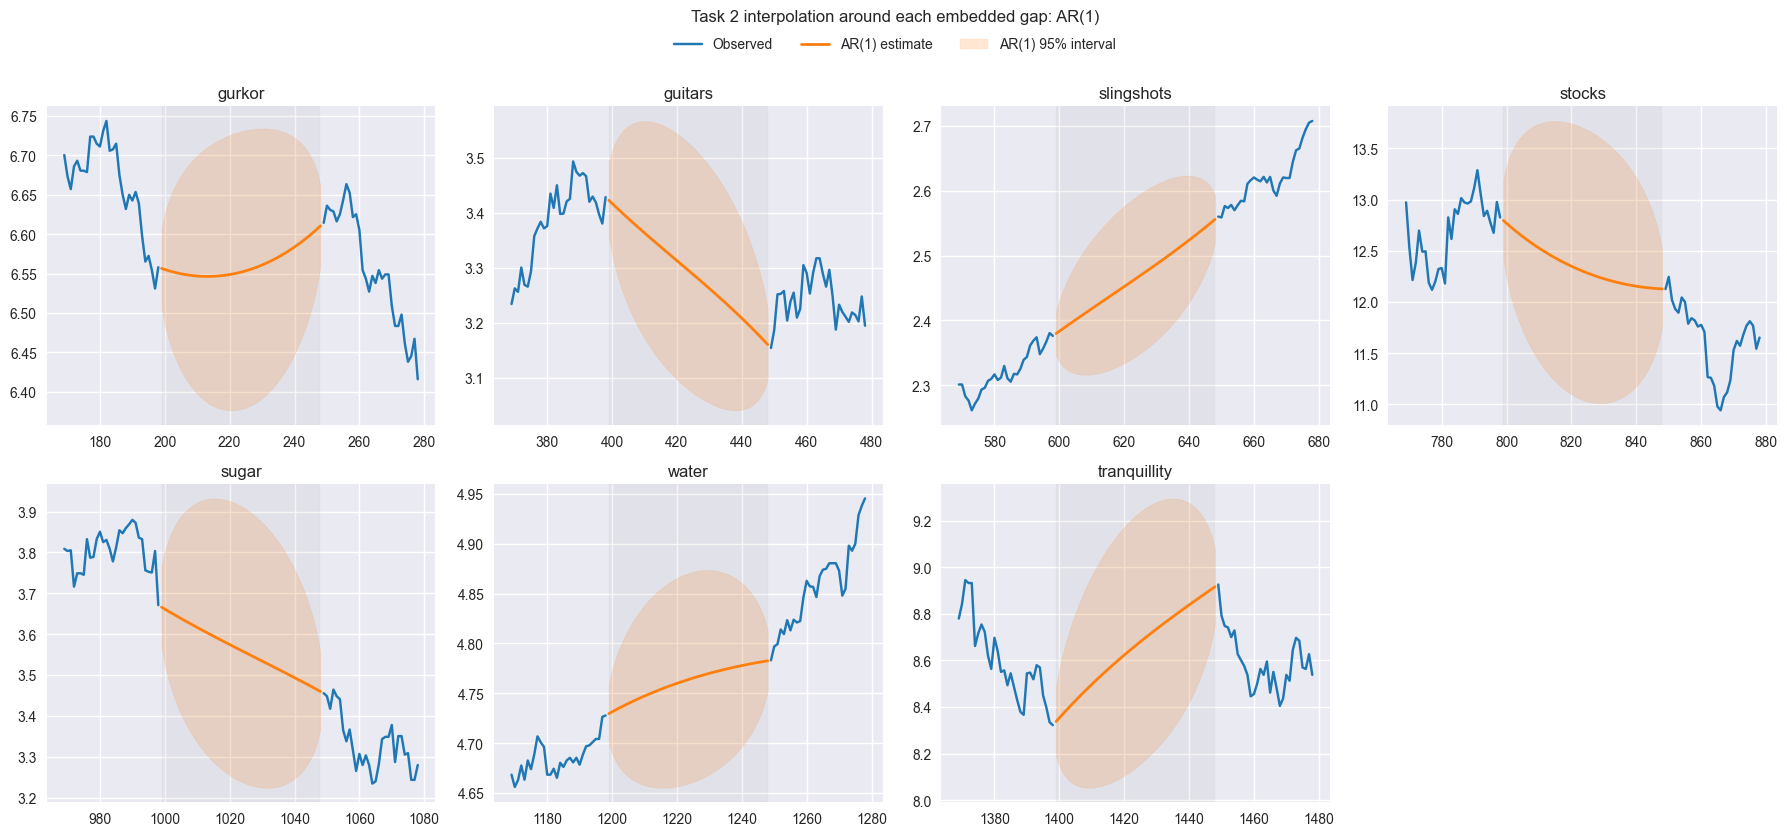

In [27]:
display_interpolation_method("ar1")


### Random Walk
This section reports the random walk bridge estimates, the 95% interval for each imputed point, and the gap plots for all series.


Interpolated values with 95% uncertainty bands: Random walk


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5591,6.5090,6.6096,0.0039
1,200,gurkor,6.5602,6.4902,6.6310,0.0055
2,201,gurkor,6.5613,6.4765,6.6472,0.0066
3,202,gurkor,6.5624,6.4656,6.6607,0.0076
4,203,gurkor,6.5635,6.4565,6.6723,0.0084
5,204,gurkor,6.5646,6.4487,6.6826,0.0091
6,205,gurkor,6.5657,6.4420,6.6918,0.0097
7,206,gurkor,6.5668,6.4361,6.7002,0.0103
8,207,gurkor,6.5679,6.4310,6.7078,0.0108
9,208,gurkor,6.5690,6.4264,6.7148,0.0112



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma
0,gurkor,Random walk,199,248,NaN,NaN,NaN,0.2908,-0.0001,0.0039,NaN,NaN,NaN,NaN
1,guitars,Random walk,399,448,NaN,NaN,NaN,0.3793,0.0003,0.0103,NaN,NaN,NaN,NaN
2,slingshots,Random walk,599,648,NaN,NaN,NaN,0.1970,0.0001,0.0071,NaN,NaN,NaN,NaN
3,stocks,Random walk,799,848,NaN,NaN,NaN,2.2042,-0.0004,0.0158,NaN,NaN,NaN,NaN
4,sugar,Random walk,999,1048,NaN,NaN,NaN,0.5546,-0.0001,0.0139,NaN,NaN,NaN,NaN
5,water,Random walk,1199,1248,NaN,NaN,NaN,0.1629,0.0004,0.0031,NaN,NaN,NaN,NaN
6,tranquillity,Random walk,1399,1448,NaN,NaN,NaN,0.8752,-0.0003,0.0091,NaN,NaN,NaN,NaN


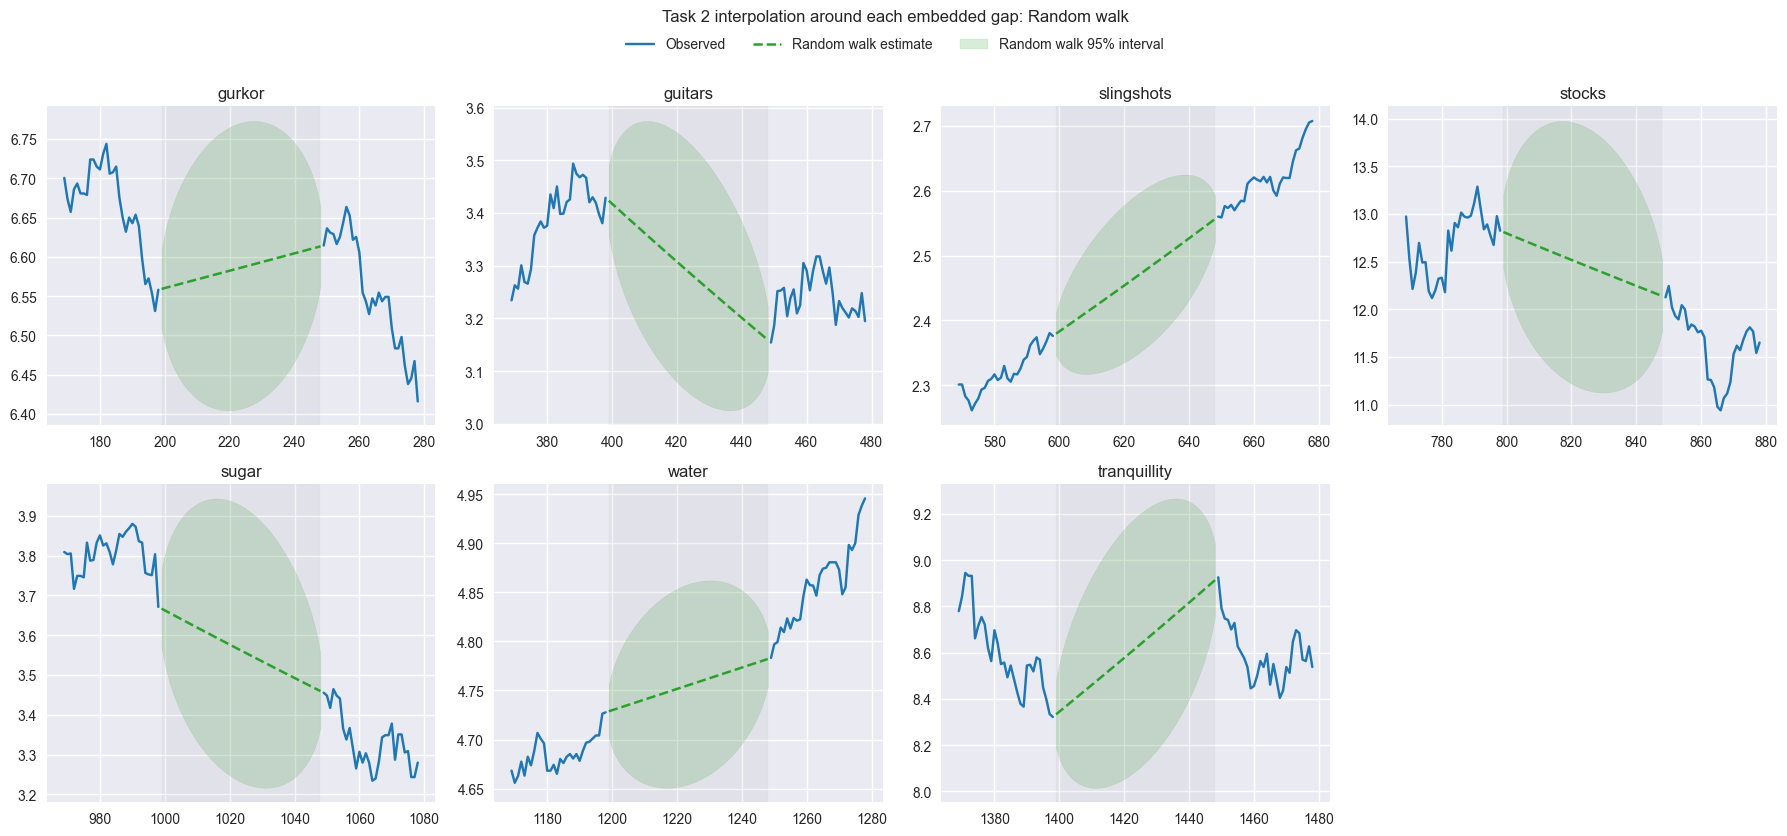

In [28]:
display_interpolation_method("random_walk")


### GARCH(1,1)
This section reports the GARCH(1,1) bridge estimates, the 95% interval for each imputed point, and the gap plots for all series.


Interpolated values with 95% uncertainty bands: GARCH(1,1)


,day,series,estimate,lower_95,upper_95,std_log
0,199,gurkor,6.5597,6.5208,6.5987,0.0030
1,200,gurkor,6.5613,6.5075,6.6155,0.0042
2,201,gurkor,6.5628,6.4983,6.6279,0.0050
3,202,gurkor,6.5643,6.4914,6.6381,0.0057
4,203,gurkor,6.5658,6.4860,6.6466,0.0062
5,204,gurkor,6.5673,6.4817,6.6540,0.0067
6,205,gurkor,6.5687,6.4782,6.6606,0.0071
7,206,gurkor,6.5701,6.4754,6.6663,0.0074
8,207,gurkor,6.5715,6.4731,6.6715,0.0077
9,208,gurkor,6.5729,6.4713,6.6761,0.0079



Series-level summary:


,series,method,gap_start_day,gap_end_day,local_mu_log_price,local_phi,innovation_sigma,mean_interval_width,drift_return,return_sigma,garch_omega,garch_alpha,garch_beta,long_run_sigma
0,gurkor,"GARCH(1,1)",199,248,NaN,NaN,NaN,0.1857,0.0000,NaN,0.0000,0.0800,0.8800,0.0020
1,guitars,"GARCH(1,1)",399,448,NaN,NaN,NaN,0.2536,0.0005,NaN,0.0000,0.0800,0.8800,0.0059
2,slingshots,"GARCH(1,1)",599,648,NaN,NaN,NaN,0.1118,0.0009,NaN,0.0000,0.0800,0.8800,0.0036
3,stocks,"GARCH(1,1)",799,848,NaN,NaN,NaN,1.6325,-0.0002,NaN,0.0000,0.0800,0.8800,0.0102
4,sugar,"GARCH(1,1)",999,1048,NaN,NaN,NaN,0.3568,0.0003,NaN,0.0000,0.0800,0.8800,0.0055
5,water,"GARCH(1,1)",1199,1248,NaN,NaN,NaN,0.0813,0.0004,NaN,0.0000,0.0800,0.8800,0.0013
6,tranquillity,"GARCH(1,1)",1399,1448,NaN,NaN,NaN,0.5712,-0.0005,NaN,0.0000,0.0800,0.8800,0.0047


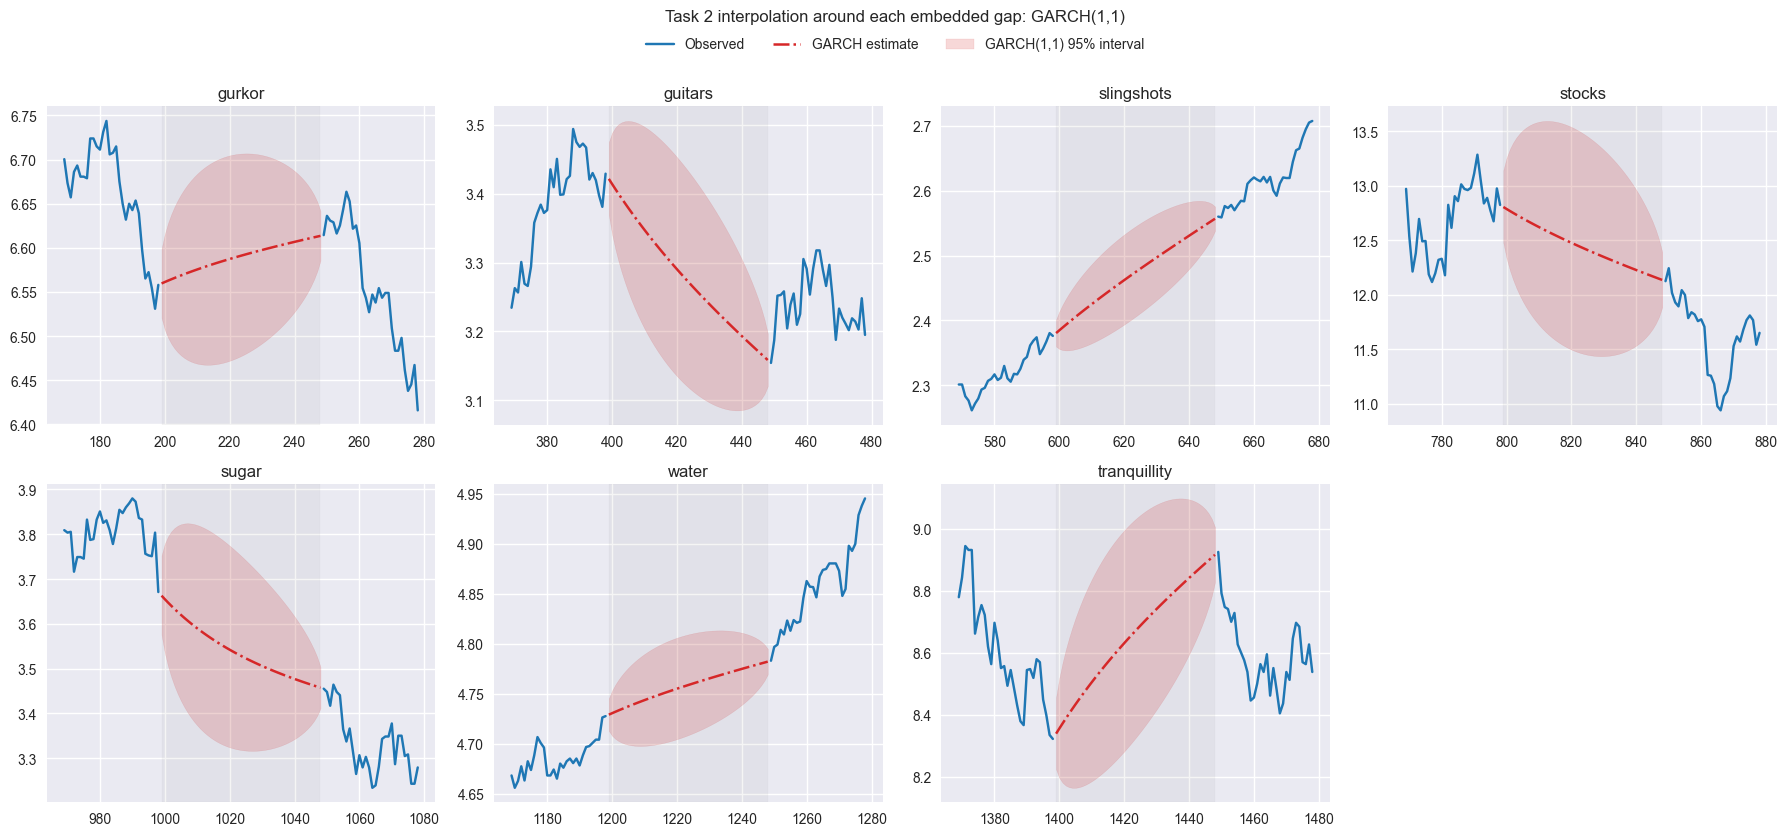

In [29]:
display_interpolation_method("garch")


## Leakage-safe evaluation
Each method is evaluated on synthetic 50-day gaps inserted into observed parts of the data. For every pseudo-gap, the model only uses information available outside the removed block, so the backtest matches the interpolation setting without leaking the true values.

The main metrics are:
- **MAE** and **RMSE** for reconstruction error.
- **95% coverage** for interval calibration.


In [30]:
def observed_segments_without_tail(series, tail_missing = TAIL_MISSING):
    # keep only observed segments that can be used for pseudo gaps
    trimmed = series.iloc[:-tail_missing]
    observed_groups = contiguous_groups(trimmed.notna())
    return [trimmed.iloc[group] for group in observed_groups if len(group) > 0]


def _backtest_interpolation_for_segment(segment, pseudo_series, start, end, method, gap_length, window):
    # apply one model to one synthetic gap
    log_segment = np.log(segment)
    left_log_price = float(log_segment.iloc[start - 1])
    right_log_price = float(log_segment.iloc[end + 1])

    if method == "ar1":
        mu, phi, sigma_eps = estimate_local_ar1_params(pseudo_series, start, end, window=window)
        estimate, lower_95, upper_95, _ = ar1_conditional_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            mu=mu,
            phi=phi,
            sigma_eps=sigma_eps,
            gap_length=gap_length,
        )
        diagnostics = {
            "local_phi": phi,
            "innovation_sigma": sigma_eps,
        }
    elif method == "random_walk":
        drift, sigma_return = estimate_local_random_walk_params(pseudo_series, start, end, window=window)
        innovation_variances = np.full(gap_length + 1, sigma_return**2)
        estimate, lower_95, upper_95, _ = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        diagnostics = {
            "drift_return": drift,
            "return_sigma": sigma_return,
        }
    elif method == "garch":
        params = estimate_local_garch_params(pseudo_series, start, end, window=window)
        innovation_variances = forecast_garch_innovation_variances(
            last_variance=params["last_variance"],
            omega=params["garch_omega"],
            alpha=params["garch_alpha"],
            beta=params["garch_beta"],
            horizon=gap_length + 1,
        )
        estimate, lower_95, upper_95, _ = variance_bridge_prices(
            left_log_price=left_log_price,
            right_log_price=right_log_price,
            innovation_variances=innovation_variances,
        )
        diagnostics = {
            "drift_return": params["drift_return"],
            "long_run_sigma": params["long_run_sigma"],
        }

    return estimate, lower_95, upper_95, diagnostics


def backtest_series(series, method, gap_length = GAP_LENGTH, window = LOCAL_WINDOW, step = 100):
    # repeat the synthetic gap test across one series
    rows = []

    for segment in observed_segments_without_tail(series):
        if len(segment) < 2 * window + gap_length + 2:
            continue

        for start in range(window, len(segment) - window - gap_length - 1, step):
            end = start + gap_length - 1
            pseudo_series = segment.copy()
            pseudo_series.iloc[start:end + 1] = np.nan

            estimate, lower_95, upper_95, diagnostics = _backtest_interpolation_for_segment(
                segment=segment,
                pseudo_series=pseudo_series,
                start=start,
                end=end,
                method=method,
                gap_length=gap_length,
                window=window,
            )

            actual = segment.iloc[start:end + 1].to_numpy()
            rows.append(
                {
                    "series": series.name,
                    "method": METHOD_LABELS[method],
                    "segment_start_day": int(segment.index[start]),
                    "segment_end_day": int(segment.index[end]),
                    **diagnostics,
                    "mae": float(np.mean(np.abs(actual - estimate))),
                    "rmse": float(np.sqrt(np.mean((actual - estimate) ** 2))),
                    "coverage_95": float(np.mean((actual >= lower_95) & (actual <= upper_95))),
                }
            )

    return pd.DataFrame(rows)


# aggregate backtest results across all models and series
backtest_results = pd.concat(
    [
        backtest_series(data[column], method=method)
        for method in INTERPOLATION_METHODS
        for column in data.columns
    ],
    ignore_index=True,
)
backtest_summary = backtest_results.groupby(["method", "series"], as_index=False).agg(
    mean_mae=("mae", "mean"),
    mean_rmse=("rmse", "mean"),
    mean_coverage_95=("coverage_95", "mean"),
    pseudo_gap_count=("coverage_95", "size"),
)
backtest_method_summary = backtest_results.groupby("method", as_index=False).agg(
    overall_mae=("mae", "mean"),
    overall_rmse=("rmse", "mean"),
    overall_coverage_95=("coverage_95", "mean"),
    pseudo_gap_count=("coverage_95", "size"),
)
backtest_method_summary["coverage_gap"] = (backtest_method_summary["overall_coverage_95"] - 0.95).abs()
backtest_method_summary = backtest_method_summary.sort_values(
    ["overall_rmse", "overall_mae", "coverage_gap"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(backtest_summary)
display(backtest_method_summary)


/Users/albinessman/Chalmers/fts/project_FTS/.venv/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


,method,series,mean_mae,mean_rmse,mean_coverage_95,pseudo_gap_count
0,AR(1),guitars,0.1737,0.2112,0.9581,43
1,AR(1),gurkor,0.0793,0.0943,0.9484,45
2,AR(1),slingshots,0.1012,0.1222,0.9633,42
3,AR(1),stocks,0.1978,0.2392,0.9457,42
4,AR(1),sugar,0.0737,0.0874,0.9548,42
...,...,...,...,...,...,...
16,Random walk,slingshots,0.0960,0.1169,0.9710,42
17,Random walk,stocks,0.1941,0.2339,0.9529,42
18,Random walk,sugar,0.0740,0.0883,0.9576,42
19,Random walk,tranquillity,0.3031,0.3675,0.9676,42


,method,overall_mae,overall_rmse,overall_coverage_95,pseudo_gap_count,coverage_gap
0,Random walk,0.1364,0.1647,0.9572,298,0.0072
1,AR(1),0.1393,0.1681,0.9526,298,0.0026
2,"GARCH(1,1)",0.1428,0.1714,0.7997,298,0.1503


## Result
The table below ranks the three interpolation methods on the backtest. The main selection criterion is overall RMSE, with MAE and 95% coverage used as supporting checks. 

In [31]:
# pick the top ranked model from the backtest table
best_method = backtest_method_summary.iloc[0]
best_method_name = best_method["method"]

result_table = backtest_method_summary.copy()
result_table["is_best"] = ["best" if idx == 0 else "" for idx in result_table.index]

display(result_table)
print(
    f"Best solution: {best_method_name} "
    f"(RMSE={best_method['overall_rmse']:.4f}, "
    f"MAE={best_method['overall_mae']:.4f}, "
    f"coverage={best_method['overall_coverage_95']:.3f})."
)


,method,overall_mae,overall_rmse,overall_coverage_95,pseudo_gap_count,coverage_gap,is_best
0,Random walk,0.1364,0.1647,0.9572,298,0.0072,best
1,AR(1),0.1393,0.1681,0.9526,298,0.0026,
2,"GARCH(1,1)",0.1428,0.1714,0.7997,298,0.1503,


Best solution: Random walk (RMSE=0.1647, MAE=0.1364, coverage=0.957).
